# QML Bladder Tissue Classification — EBTC
**Option A: Cancer (HGC+LGC) vs Non-Cancer (NST+NTL)**

| | v1 | v2 |
|---|---|---|
| Qubits | 4 | 6 |
| Feature Map | ZZFeatureMap | PauliFeatureMap (Z+ZZ+ZZZ) |
| Ansatz | RealAmplitudes | EfficientSU2 |
| Observable | Z⊗I⊗I⊗I | Σ Z_i (all-qubit Z sum) |

## Cell 1: Install Packages (first time only)

In [1]:
# # Run this cell only once. Comment out after the first run.
# import sys
# !{sys.executable} -m pip install qiskit qiskit-machine-learning qiskit-algorithms \
#     torch torchvision scikit-learn numpy pandas matplotlib pillow -

# import sys
# !{sys.executable} -m pip install qiskit-aer -q

## Cell 2: Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

print('Imports OK')

Imports OK


## Cell 3: Feature Extraction (heavy — run once, then skip to Cell 4)

Extracts 512-dim features from each image using a frozen ResNet-18,  
then reduces to 4 / 6 dimensions via PCA and scales to [-π, π] for angle encoding.  
Results are saved as `.npy` files so this step can be skipped on subsequent runs.

In [3]:
from data_loader_ebtc import extract_features

DATA_DIR    = '.'    # folder containing HGC/ LGC/ NST/ NTL/
MAX_SAMPLES = 300    # keep this low to make QML simulation feasible
SEED        = 42

print('=== 4-qubit features (v1) ===')
X4, y = extract_features(DATA_DIR, n_features=4,
                         max_samples=MAX_SAMPLES, seed=SEED)

print('\n=== 6-qubit features (v2) ===')
X6, _ = extract_features(DATA_DIR, n_features=6,
                         max_samples=MAX_SAMPLES, seed=SEED)

# Save to disk so Cell 3 can be skipped next time
np.save('X4.npy', X4)
np.save('X6.npy', X6)
np.save('y.npy',  y)
print('\nSaved: X4.npy, X6.npy, y.npy')

=== 4-qubit features (v1) ===
[EBTCDataset] Loaded 1754 images from .
  class 0 (non-cancer): 638  |  class 1 (cancer): 1116
[extract_features] After balancing: N=400, class ratio=0.500
[extract_features] PCA variance retained: 30.9% (4 components from 512)

=== 6-qubit features (v2) ===
[EBTCDataset] Loaded 1754 images from .
  class 0 (non-cancer): 638  |  class 1 (cancer): 1116
[extract_features] After balancing: N=400, class ratio=0.500
[extract_features] PCA variance retained: 38.4% (6 components from 512)

Saved: X4.npy, X6.npy, y.npy


## Cell 4: Load Features from Disk (start here from the 2nd run onwards)

In [4]:
X4 = np.load('X4.npy')
X6 = np.load('X6.npy')
y  = np.load('y.npy')

print(f'X4: {X4.shape},  X6: {X6.shape},  y: {y.shape}')
print(f'Feature range: [{X4.min():.2f}, {X4.max():.2f}]')
print(f'Cancer ratio:  {y.mean():.3f}')

X4: (400, 4),  X6: (400, 6),  y: (400,)
Feature range: [-3.14, 3.14]
Cancer ratio:  0.500


## Cell 5: Train / Test Split

In [5]:
SEED = 42

X4tr, X4te, y4tr, y4te = train_test_split(
    X4, y, test_size=0.25, stratify=y, random_state=SEED)
X6tr, X6te, y6tr, y6te = train_test_split(
    X6, y, test_size=0.25, stratify=y, random_state=SEED)

print(f'Train: {len(y4tr)},  Test: {len(y4te)}')
print(f'Cancer ratio (train): {y4tr.mean():.3f}')

Train: 300,  Test: 100
Cancer ratio (train): 0.500


## Cell 6: Instantiate Models

Set `FAST = True` for a quick smoke-test (fewer iterations).  
Set `FAST = False` for the full benchmark.

In [6]:
from models    import QSVMClassifier as QSVM1, VQCClassifier as VQC1
from models    import QKernelSVMClassifier as QK1, QNNClassifier as QNN1
from models_v2 import QSVMClassifier as QSVM2, VQCClassifier as VQC2
from models_v2 import QKernelSVMClassifier as QK2, QNNClassifier as QNN2

FAST = True   # set to False for full-length training

v1_models = {
    'QSVM':        QSVM1(n_qubits=4),
    'VQC':         VQC1 (n_qubits=4, max_iter=30  if FAST else 100),
    'QKernel+SVM': QK1  (n_qubits=4),
    'QNN':         QNN1 (n_qubits=4, epochs=10 if FAST else 30),
}
v2_models = {
    'QSVM':        QSVM2(n_qubits=6),
    'VQC':         VQC2 (n_qubits=6, max_iter=30  if FAST else 150),
    'QKernel+SVM': QK2  (n_qubits=6),
    'QNN':         QNN2 (n_qubits=6, epochs=10 if FAST else 40),
}
print(f'Models ready  |  FAST = {FAST}')

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Models ready  |  FAST = True


## Cell 7: Run v1 Models (4 qubits)

In [7]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    """Train model and return accuracy, F1, AUC, train time, and confusion matrix."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    yp  = model.predict(X_te)
    acc = accuracy_score(y_te, yp)
    f1  = f1_score(y_te, yp, zero_division=0)

    # Compute AUC from probability scores when available
    try:
        m = getattr(model, 'model', None)
        if m and hasattr(m, 'predict_proba'):
            prob = m.predict_proba(X_te)[:, 1]
        elif m and hasattr(m, 'decision_function'):
            prob = m.decision_function(X_te)
        else:
            prob = yp.astype(float)
        auc = roc_auc_score(y_te, prob)
    except Exception:
        auc = float('nan')

    return dict(acc=acc, f1=f1, auc=auc, time=elapsed,
                yp=yp, cm=confusion_matrix(y_te, yp))


MODEL_NAMES = ['QSVM', 'VQC', 'QKernel+SVM', 'QNN']

v1_res = {}
for name, model in v1_models.items():
    print(f'\n[v1] {name} ...')
    try:
        r = evaluate(model, X4tr, y4tr, X4te, y4te)
        v1_res[name] = r
        print(f'  acc={r["acc"]:.3f}  f1={r["f1"]:.3f}  '
              f'auc={r["auc"]:.3f}  time={r["time"]:.1f}s')
    except Exception as e:
        print(f'  FAILED: {e}')
        v1_res[name] = dict(acc=0, f1=0, auc=0, time=0,
                            yp=np.array([]), cm=np.zeros((2,2), int))


[v1] QSVM ...
  acc=0.720  f1=0.720  auc=0.804  time=101.3s

[v1] VQC ...
  acc=0.520  f1=0.489  auc=0.520  time=15.6s

[v1] QKernel+SVM ...
  acc=0.690  f1=0.693  auc=0.690  time=100.7s

[v1] QNN ...
    [QNN] epoch   5/10 | loss = 0.6947
    [QNN] epoch  10/10 | loss = 0.6918
  acc=0.590  f1=0.586  auc=0.590  time=15.4s


## Cell 8: Run v2 Models (6 qubits)

In [8]:
v2_res = {}
for name, model in v2_models.items():
    print(f'\n[v2] {name} ...')
    try:
        r = evaluate(model, X6tr, y6tr, X6te, y6te)
        v2_res[name] = r
        print(f'  acc={r["acc"]:.3f}  f1={r["f1"]:.3f}  '
              f'auc={r["auc"]:.3f}  time={r["time"]:.1f}s')
    except Exception as e:
        print(f'  FAILED: {e}')
        v2_res[name] = None


[v2] QSVM ...
  acc=0.870  f1=0.885  auc=0.909  time=496.2s

[v2] VQC ...
  acc=0.500  f1=0.500  auc=0.512  time=107.5s

[v2] QKernel+SVM ...
  acc=0.860  f1=0.877  auc=0.860  time=485.8s

[v2] QNN ...
    [QNN] epoch  10/10 | loss=0.3306
  acc=0.820  f1=0.809  auc=0.820  time=375.5s


## Cell 9: Results Summary Table

In [9]:
rows = []
for n in MODEL_NAMES:
    r1 = v1_res.get(n, {})
    r2 = v2_res.get(n) or {}
    rows.append({
        'Model':  n,
        'v1 Acc': round(r1.get('acc', 0), 3),
        'v2 Acc': round(r2.get('acc', 0), 3) if r2 else 'N/A',
        'Delta':  round(r2.get('acc', 0) - r1.get('acc', 0), 3) if r2 else 'N/A',
        'v1 F1':  round(r1.get('f1',  0), 3),
        'v2 F1':  round(r2.get('f1',  0), 3) if r2 else 'N/A',
        'v2 AUC': round(r2.get('auc', 0), 3) if r2 else 'N/A',
    })

df = pd.DataFrame(rows)
display(df)

import os
os.makedirs('results', exist_ok=True)
df.to_csv('results/ebtc_metrics.csv', index=False)
print('Saved: results/ebtc_metrics.csv')

,Model,v1 Acc,v2 Acc,Delta,v1 F1,v2 F1,v2 AUC
0,QSVM,0.72,0.87,0.15,0.720,0.885,0.909
1,VQC,0.52,0.50,-0.02,0.489,0.500,0.512
2,QKernel+SVM,0.69,0.86,0.17,0.693,0.877,0.860
3,QNN,0.59,0.82,0.23,0.586,0.809,0.820


Saved: results/ebtc_metrics.csv


## Cell 10: Visualisation

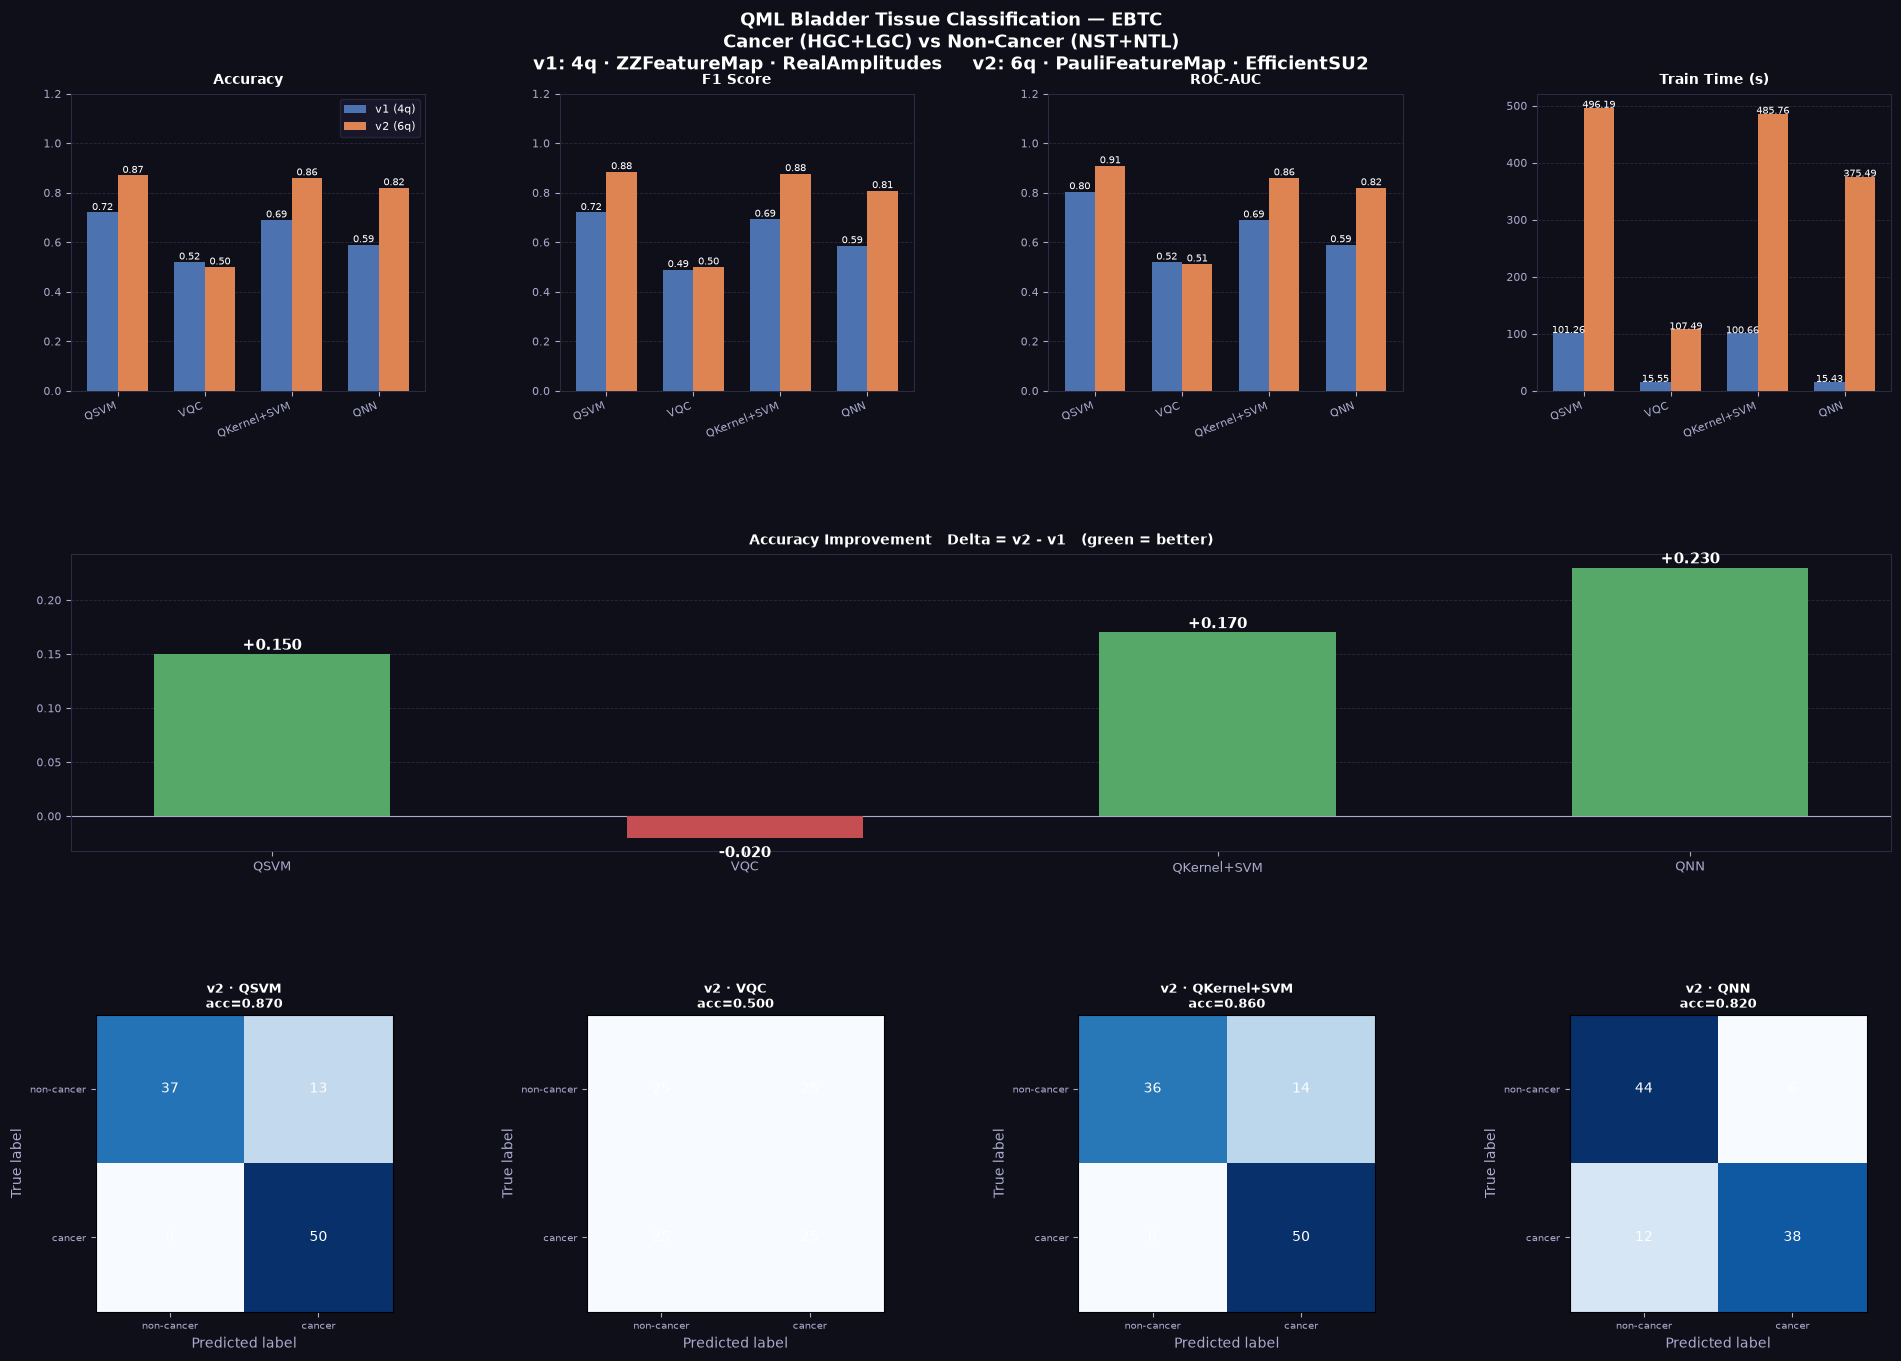

Saved: results/ebtc_final.png


In [10]:
# Color palette
BG   = '#0f0f1a'
GRD  = '#2a2a40'
LC   = '#aaaacc'
CV1  = '#4C72B0'
CV2  = '#DD8452'
CPOS = '#55A868'
CNEG = '#C44E52'

x = np.arange(len(MODEL_NAMES))
w = 0.35

fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle(
    'QML Bladder Tissue Classification — EBTC\n'
    'Cancer (HGC+LGC) vs Non-Cancer (NST+NTL)\n'
    'v1: 4q · ZZFeatureMap · RealAmplitudes     '
    'v2: 6q · PauliFeatureMap · EfficientSU2',
    color='white', fontsize=13, fontweight='bold', y=0.98)

outer = gridspec.GridSpec(3, 1, figure=fig, hspace=0.55,
                          top=0.92, bottom=0.05, left=0.06, right=0.97)

def ax_style(ax, title, ylim=None):
    ax.set_facecolor(BG)
    ax.set_title(title, color='white', fontsize=10, fontweight='bold', pad=7)
    ax.tick_params(colors=LC, labelsize=8)
    ax.yaxis.grid(True, color=GRD, linestyle='--', lw=0.6)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRD)
    if ylim:
        ax.set_ylim(*ylim)

# --- Row 0: grouped bar charts (Accuracy / F1 / AUC / Train Time) ---
row0 = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[0], wspace=0.38)
for col, (met, mlab) in enumerate([('acc', 'Accuracy'), ('f1', 'F1 Score'),
                                    ('auc', 'ROC-AUC'), ('time', 'Train Time (s)')]):
    ax  = fig.add_subplot(row0[col])
    v1v = [v1_res.get(n, {}).get(met, 0) or 0 for n in MODEL_NAMES]
    v2v = [v2_res[n].get(met, 0) if v2_res.get(n) else 0 for n in MODEL_NAMES]
    b1  = ax.bar(x - w/2, v1v, w, color=CV1, label='v1 (4q)', zorder=3)
    ax.bar(x + w/2, v2v, w, color=CV2, label='v2 (6q)', zorder=3)
    ax_style(ax, mlab, (0, 1.2) if met != 'time' else None)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_NAMES, rotation=22, ha='right', fontsize=8)
    # value labels on bars
    for bar, v in zip(b1, v1v):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.2f}', ha='center', color='white', fontsize=7)
    for i, v in enumerate(v2v):
        if v2_res.get(MODEL_NAMES[i]) and not np.isnan(v):
            ax.text(x[i] + w/2, v + 0.01,
                    f'{v:.2f}', ha='center', color='white', fontsize=7)
    if col == 0:
        ax.legend(fontsize=8, labelcolor='white',
                  facecolor='#1a1a2e', edgecolor=GRD)

# --- Row 1: accuracy improvement delta bar ---
ax_d   = fig.add_subplot(outer[1])
deltas = [v2_res[n]['acc'] - v1_res[n]['acc']
          if v2_res.get(n) else 0 for n in MODEL_NAMES]
dcols  = [CPOS if d >= 0 else CNEG for d in deltas]
bars   = ax_d.bar(MODEL_NAMES, deltas, color=dcols, width=0.5, zorder=3)
ax_style(ax_d, 'Accuracy Improvement   Delta = v2 - v1   (green = better)')
ax_d.axhline(0, color=LC, lw=0.8)
for bar, d in zip(bars, deltas):
    yp = bar.get_height() + 0.004 if d >= 0 else bar.get_height() - 0.018
    ax_d.text(bar.get_x() + bar.get_width()/2, yp, f'{d:+.3f}',
              ha='center', color='white', fontsize=11, fontweight='bold')
ax_d.set_xticklabels(MODEL_NAMES, color=LC, fontsize=9)

# --- Row 2: confusion matrices for v2 ---
row2 = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[2], wspace=0.42)
for col, name in enumerate(MODEL_NAMES):
    ax  = fig.add_subplot(row2[col])
    ax.set_facecolor(BG)
    r   = v2_res.get(name)
    cm  = r['cm']  if r else np.zeros((2, 2), int)
    acc = r['acc'] if r else 0
    disp = ConfusionMatrixDisplay(cm, display_labels=['non-cancer', 'cancer'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(f'v2 · {name}\nacc={acc:.3f}',
                 color='white', fontsize=9, fontweight='bold', pad=5)
    ax.tick_params(colors=LC, labelsize=7)
    ax.xaxis.label.set_color(LC)
    ax.yaxis.label.set_color(LC)
    for txt in ax.texts:
        txt.set_color('white')

import os
os.makedirs('results', exist_ok=True)
plt.savefig('results/ebtc_final.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: results/ebtc_final.png')

In [11]:
from models_v1_aer import (QSVMClassifier as QSVM1_aer, VQCClassifier as VQC1_aer,
                            QKernelSVMClassifier as QK1_aer, QNNClassifier as QNN1_aer)

FAST = True

v1_aer_models = {
    'QSVM':        QSVM1_aer(n_qubits=4, shots=1024),
    'VQC':         VQC1_aer (n_qubits=4, shots=1024, max_iter=30 if FAST else 100),
    'QKernel+SVM': QK1_aer  (n_qubits=4, shots=1024),
    'QNN':         QNN1_aer (n_qubits=4, shots=1024, epochs=10 if FAST else 30),
}
print(f'v1 Aer models ready  |  4 qubits  |  AerSimulator 1024 shots')

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


v1 Aer models ready  |  4 qubits  |  AerSimulator 1024 shots


In [12]:
v1_aer_res = {}
for name, model in v1_aer_models.items():
    print(f'\n[v1 Aer] {name} ...')
    try:
        r = evaluate(model, X4tr, y4tr, X4te, y4te)
        v1_aer_res[name] = r
        print(f'  acc={r["acc"]:.3f}  f1={r["f1"]:.3f}  '
              f'auc={r["auc"]:.3f}  time={r["time"]:.1f}s')
    except Exception as e:
        print(f'  FAILED: {e}')
        v1_aer_res[name] = None


[v1 Aer] QSVM ...
  acc=0.700  f1=0.706  auc=0.803  time=1523.5s

[v1 Aer] VQC ...
  acc=0.470  f1=0.514  auc=0.492  time=6.7s

[v1 Aer] QKernel+SVM ...
  acc=0.680  f1=0.680  auc=0.680  time=1936.4s

[v1 Aer] QNN ...
    [QNN] epoch  10/10 | loss=0.6915
  acc=0.610  f1=0.598  auc=0.610  time=19.2s


In [14]:
rows = []
for n in MODEL_NAMES:
    r_sv  = v1_res.get(n) or {}
    r_aer = v1_aer_res.get(n) or {}
    rows.append({
        'Model':       n,
        'v1_SV Acc':   round(r_sv.get('acc',  0), 3) if r_sv  else 'N/A',
        'v1_Aer Acc':  round(r_aer.get('acc', 0), 3) if r_aer else 'N/A',
        'Delta':       round(r_aer.get('acc', 0) - r_sv.get('acc', 0), 3)
                       if (r_sv and r_aer) else 'N/A',
        'v1_SV F1':    round(r_sv.get('f1',  0), 3) if r_sv  else 'N/A',
        'v1_Aer F1':   round(r_aer.get('f1', 0), 3) if r_aer else 'N/A',
        'SV Time(s)':  round(r_sv.get('time',  0), 1) if r_sv  else 'N/A',
        'Aer Time(s)': round(r_aer.get('time', 0), 1) if r_aer else 'N/A',
    })

df_compare = pd.DataFrame(rows)
display(df_compare)
import os; os.makedirs('results', exist_ok=True)
df_compare.to_csv('results/sv_vs_aer_v1.csv', index=False)
print('Saved: results/sv_vs_aer_v1.csv')

,Model,v1_SV Acc,v1_Aer Acc,Delta,v1_SV F1,v1_Aer F1,SV Time(s),Aer Time(s)
0,QSVM,0.72,0.70,-0.02,0.720,0.706,101.3,1523.5
1,VQC,0.52,0.47,-0.05,0.489,0.514,15.6,6.7
2,QKernel+SVM,0.69,0.68,-0.01,0.693,0.680,100.7,1936.4
3,QNN,0.59,0.61,0.02,0.586,0.598,15.4,19.2


Saved: results/sv_vs_aer_v1.csv


In [17]:
!pip install pylatexenc

  Using cached pylatexenc-2.10-py3-none-any.whl


In [19]:
import warnings
warnings.filterwarnings('ignore')

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

n_qubits = 4
reps     = 2

# Build circuits
feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=reps)
ansatz      = RealAmplitudes(n_qubits, reps=reps)
qc_full     = feature_map.compose(ansatz)

# Transpile for AerSimulator
backend = AerSimulator()
pm      = generate_preset_pass_manager(optimization_level=1, backend=backend)
qc_transpiled = pm.run(qc_full)

# Output circuit info
print('=== v1 Circuit Info ===')
print(f'Qubits:              {n_qubits}')
print(f'Feature map:         ZZFeatureMap  (reps={reps})')
print(f'Ansatz:              RealAmplitudes (reps={reps})')
print()
print('--- Before transpilation ---')
print(f'Depth:               {qc_full.depth()}')
print(f'Total gates:         {sum(qc_full.count_ops().values())}')
print(f'Gate breakdown:      {dict(qc_full.count_ops())}')
print()
print('--- After transpilation (AerSimulator) ---')
print(f'Depth:               {qc_transpiled.depth()}')
print(f'Total gates:         {sum(qc_transpiled.count_ops().values())}')
print(f'Gate breakdown:      {dict(qc_transpiled.count_ops())}')
print()

# Draw circuit (before transpilation, text mode)
print('--- Circuit Diagram (feature map + ansatz, before transpile) ---')
print(qc_full.decompose().draw(output='text', fold=120))

=== v1 Circuit Info ===
Qubits:              4
Feature map:         ZZFeatureMap  (reps=2)
Ansatz:              RealAmplitudes (reps=2)

--- Before transpilation ---
Depth:               2
Total gates:         2
Gate breakdown:      {'ZZFeatureMap': 1, 'RealAmplitudes': 1}

--- After transpilation (AerSimulator) ---
Depth:               39
Total gates:         70
Gate breakdown:      {'cx': 30, 'p': 20, 'ry': 12, 'h': 8}

--- Circuit Diagram (feature map + ansatz, before transpile) ---
     ┌───┐┌───────────┐                                                                                          »
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■────■──────────────────────────────────■─────────■──»
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐  │                                  │         │  »
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├──┼──────────────────────────────────┼────■────┼──»
     ├───┤├───────────┤└───┘└────────────────────